## Laboratorio clase 19: Entenamiento, deployment y MLOps
### Instrucciones:
#### 1) Este es un cuadernillo autocontenido, es decir, no necesita ejecutar o instalar nada externo para funcionar

#### 2) Las preguntas pueden aparecer en formato alternativas o de desarrollo.

In [ ]:
from IPython.utils import io
with io.capture_output() as captured:
  !pip install bentoml==1.3.2
  !pip install pydantic==2.8.2

In [ ]:
import requests
import time
import json
import numpy as np
import cv2

## Parte 1

Imagine que usted es lider cloud de un equipo de IA. La Startup "Space Z" se contacta con usted para realizar un proyecto. El objetivo principal es desarrollar una plataforma para contar tiempos de esperas de los vehiculos en las entradas/salidas de un parking a través de cámaras instaladas en cada una de ellas. Al ser una startup, tienen un presupuesto limitado de gastos al mes.

La solución planteada por su equipo es utilizar un modelo de reconocimiento de objetos ya entrenado en automoviles, el cual es ligero y rápido.

Necesitan que plantees el despliegue del módulo de IA bajo los siguientes requisitos:

1) No cuentan con servidores propios

2) El parking tiene 2 entradas

3) El modelo planteado por tu equipo puede ser ejecutado en 3 cámaras simultáneamente utilizando una GPU NVIDIA tesla T4

## Considerando el contexto planteado ¿Cuál de las siguientes alternativas son opciones viables para despliegue? seleccione una o más alternativas

a) Ya que la startup no cuenta con servidores propios, es importante armar un presupuesto para la adquisición de un computador equipado con una NVIDIA Tesla T4 para realizar el despliegue del módulo de IA. De esta manera, los gastos se realizarán una sola vez, lo que representará un ahorro a largo plazo.

b) Debido a que la startup tiene un presupuesto límite mensual, lo mejor es hacer el despliegue en cloud. Considerando que el sistema es para 1 parking con 2 cámaras procesando, no es necesario escalar. Un despliegue en una máquina virtual equipada con una NVIDIA tesla T4, es la mejor opción, obteniendo una reducción significativa en tiempo de desarrollo y complejidad de la solución en comparación con la opción planteada en c).

c) Debido a que la startup tiene un presupuesto límite mensual, lo mejor es hacer el despliegue en cloud. Si bien el sistema inicial está diseñado para 1 parking con 2 cámaras, es recomendable proyectar un crecimiento futuro, es decir, poder abordar un número mayor de parkings. Para esto, la mejor opción es el despliegue escalado del módulo IA, utilizando endpoint de vertex AI, equipados con una NVIDIA tesla T4.

______________________________________________________________________________





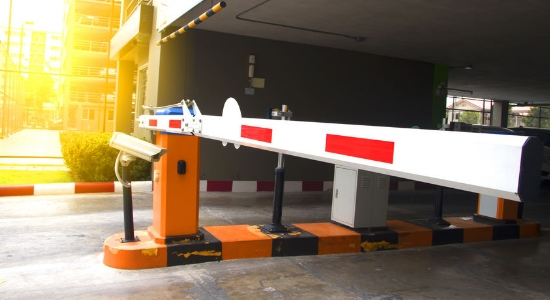

# Parte 2


Creamos server.py que al ejecutarlo despliega localmente el modelo. En este caso el modelo realiza una prediccion dummy utilizando la funcion print()

In [ ]:
#Creamos un archivo de modelo API
a="""import bentoml
from bentoml.io import JSON
import numpy as np
import torch
import cv2
import typing as t

## se define el modelo como clase
class modelo(bentoml.Runnable):
    SUPPORTED_RESOURCES = ("cpu",)
    SUPPORTS_CPU_MULTI_THREADING=False
    def __init__(self):
        print("")
    @bentoml.Runnable.method(batchable=False)
    def predict(self,image):
        print("prediccion")

##Se carga el modelo como clase a BentoML
runner = t.cast(
    "RunnerImpl", bentoml.Runner(modelo, name="modelo")
)
svc = bentoml.Service("example", runners=[runner])

##se define la API , cuando hacemos la request, se ejecuta esta seccion de codigo
@svc.api(input=JSON(), output=JSON())
async def classify(input_series) -> np.ndarray:
    image = np.array(input_series["image"], dtype=np.float32).transpose(1,2,0) #se lee la imagen desde la request
    runner.predict.async_run(image) # se realiza la prediccion sobre la imagen
    return {"predict": 200}
 """

file=open("server.py", 'w')
file.write(a)
file.close()

In [ ]:
#Se lanza en segundo plano el proceso API
get_ipython().system_raw('BENTOML_PORT=8000 bentoml serve server:svc &')


In [ ]:
#Se realiza el test de la API, si esta celda se ejecuta correctamente, indica que la API está levantada
from google.colab import output
time.sleep(10)
output.serve_kernel_port_as_iframe(8000)
pred = requests.post("http://localhost:8000/classify/", json = {"image": np.zeros((3,640,640)).tolist() } )


<IPython.core.display.Javascript object>

Considere una lista de dimensiones desde 640 hasta 3028. Realice predicciones para 4 tamaños distintos de imagen (3,shape,shape) de valores 0. Tome los tiempos de ejecución promedio para cada uno (con una muestra tamaño 3 para cada uno basta). Responda las preguntas a continuacion

1- ¿Existe alguna diferencia de tiempo de "inferencia"? ¿A que crees que se deba?

In [ ]:
### El código realiza un post a la url donde está alojado el modelo API, entregando en el cuerpo de la request una
### imagen compuesta de ceros

shapes = [640, 1024, 2048 , 3028]
url = 'http://localhost:8000/classify/'

t_i = time.time()
pred = requests.post(url, json = {"image": np.zeros((3,640,640)).tolist() } )
print(time.time()-t_i ," secs")
pred = json.loads(pred.text)
print(pred)

0.9089093208312988  secs
{'predict': 200}


Anteriormente se ve la implicancia de el tamaño de los datos en las predicciones del modelo API. Otro enfoque interesante es realizar análisis al hacer multiples predicciones al mismo tiempo. Cambie el código de a continuación para ir variando la cantidad de procesos que realizan simultáneamente predicciones (entre 2 y 10 procesos) y responda:

1 ¿Qué sucede con el tiempo de predicción a medida que la cantidad de procesos aumenta? ¿A que se debe?

In [ ]:
### Se realizan predicciones en paralelo, cada n proceso definido imprimirá un tiempo individual

from multiprocessing import Process

n_process = 2
url = 'http://localhost:8000/classify/'

def predict():
  t_i = time.time()
  pred = requests.post(url, json = {"image": np.zeros((3,640,640)).tolist() } )
  time_ex= time.time()-t_i
  pred = json.loads(pred.text)
  print(time_ex)

process =[Process(target=predict)  for x in range(n_process)]
[process_x.start() for process_x in process]
[process_x.join() for process_x in process];

1.7156195640563965
1.7288551330566406


Existe una forma de comprimir imágenes en memoria (guardarla comprimida en una variable). veamos el siguiente código

In [ ]:
img = np.random.randint( low=0 , high=255 , size=(1024,1024,3))  #definamos una imagen ficticia random de tamaño 1024,1024
encode_param = [int(cv2.IMWRITE_JPEG_QUALITY), 90]  #parametros para la compresion
result, encimg = cv2.imencode('.jpg', img, encode_param) #comprimimos la imagen ficticia en la variable encimg

Para descomprimir una imagen comprimida (proceso inverso), basta con utilizar el método imdecode()


In [ ]:
print(encimg.shape)
decimg = cv2.imdecode(encimg,1)
print(decimg.shape) ##volvemos a la imagen original

(939283,)
(1024, 1024, 3)


Analizamos los tamaños en memoria

In [ ]:
print(f'tamaño de la imagen sin comprimir: {img.nbytes*1e-6} MB')
print(f'tamaño de la imagen comprimida: {encimg.nbytes*1e-6} MB')
print(f'La imagen comprimida es {img.nbytes / encimg.nbytes} veces mas pequeña que la imagen sin comprimir')

tamaño de la imagen sin comprimir: 25.165824 MB
tamaño de la imagen comprimida: 0.939283 MB
La imagen comprimida es 26.79258966679904 veces mas pequeña que la imagen sin comprimir


Como podemos ver, comprimir la imagen ahorra bastante memoria.

1- ¿Cree que seria beneficioso en terminos de tiempo de ejecucion, la implementación de compresión de las imágenes antes de realizar la predicción al modelo API?
